# 🎬 Movie Recommendation System

This project builds a movie recommendation system using the MovieLens dataset. Providing content based recommendations and interactive UI using Streamlit.

## 🛠️ Tech Stack
- Python, Pandas, NumPy
- Scikit-learn (TF-IDF, Cosine Similarity)
- Matplotlib
- Streamlit + Ngrok (for deployment)



Task 1 : Installing required libraries

In [1]:
!pip install streamlit pyngrok scikit-learn pandas numpy matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.5 MB/s eta 0:00:00


Tak 2 : Importing libraries for data handling and visualizations

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import zipfile, requests, io

Task 3 : Downloading and extracting MovieLens dataset

In [3]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
response = requests.get(url)

zip_file = zipfile.ZipFile(io.BytesIO(response.content))
zip_file.extractall()

print("Dataset downloaded and extracted successfully ✅")

Dataset downloaded and extracted successfully ✅


Task 4 : Loading and merging dataset

In [4]:
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

data = pd.merge(ratings, movies, on="movieId")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Task 6 : Data Preprocessing
- Handling missing values
- Removing duplicates
- Checking null values

In [5]:
movies['genres'] = movies['genres'].fillna("")

movies = movies.drop_duplicates(subset="title")

movies['genres_clean'] = movies['genres'].apply(lambda x: x.replace("|", " "))

print("Null values:\n", movies.isnull().sum())

movies.head()

Null values:
 movieId         0
title           0
genres          0
genres_clean    0
dtype: int64


,movieId,title,genres,genres_clean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy


Task 7 : Exploratory Data Analysis (EDA)
- Distribution of Ratings
- Top Rated Movies
- Popularity



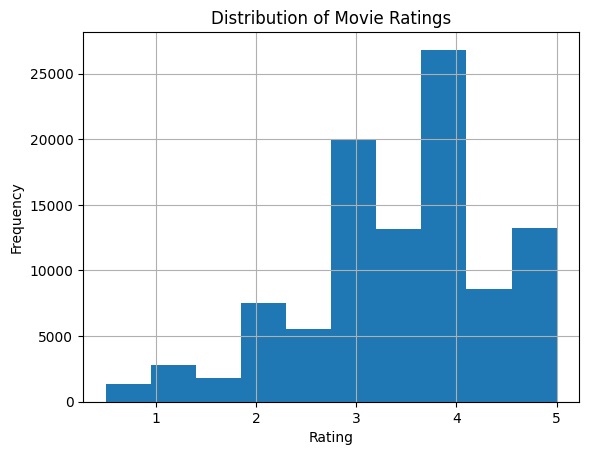

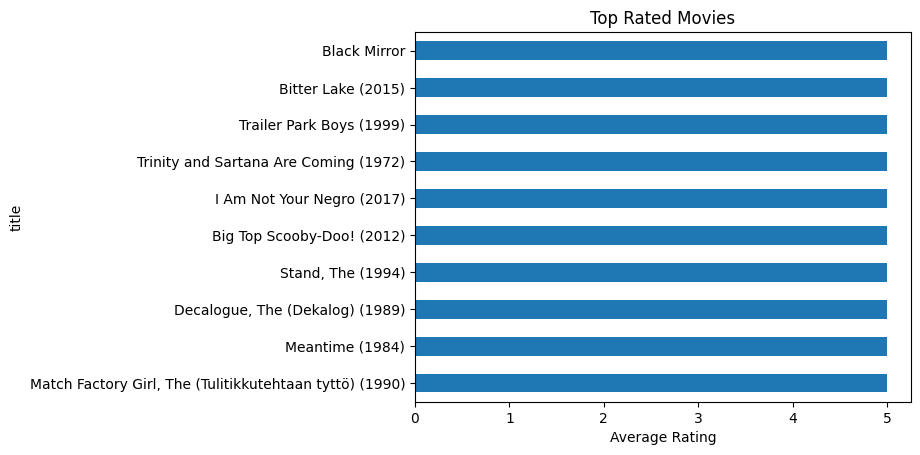

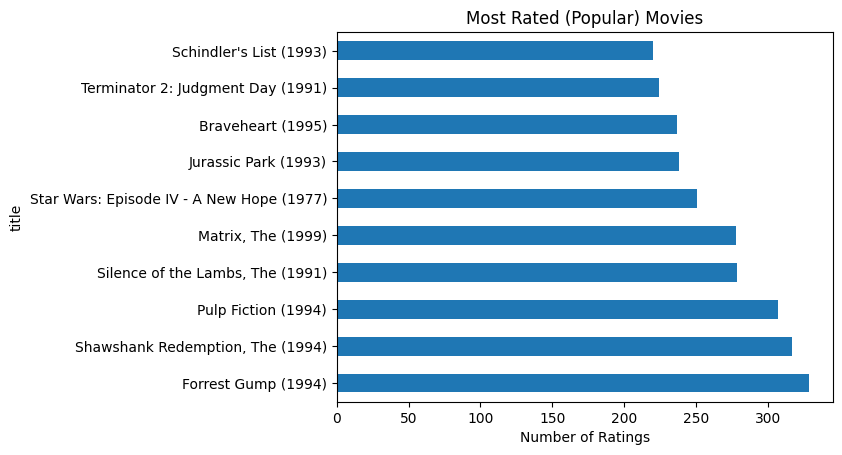

In [6]:
plt.figure()
data['rating'].hist(bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

top_movies = (
    data.groupby('title')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_movies.plot(kind='barh')
plt.title("Top Rated Movies")
plt.xlabel("Average Rating")
plt.show()

popular_movies = (
    data.groupby('title')['rating']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
popular_movies.plot(kind='barh')
plt.title("Most Rated (Popular) Movies")
plt.xlabel("Number of Ratings")
plt.show()



Task 8 : Feature Engineering using genre as the main feature for content-based filtering

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9737, 23)


Task 9 : Similarity Computation

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title'])


Task 10 : Recommendation Function
- This function takes a movie title and returns similar movies
    based on cosine similarity.

In [9]:
def recommend_movies(title, num_recommendations=5):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:num_recommendations+1]
    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]


recommend_movies("Toy Story (1995)")  #For reference

,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"


Task 11 : Save Processed Data for App

In [10]:
movies.to_csv("movies_cleaned.csv", index=False)
data.to_csv("data_merged.csv", index=False)

print("Data saved for deployment ✅")

Data saved for deployment ✅


Task 12 : Streamlit App UI

In [ ]:
TMDB_API_KEY = "YOUR_API_KEY"  # for poster images

In [15]:
%%writefile app.py

import streamlit as st
import pandas as pd
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

st.set_page_config(page_title="Movie Recommender", layout="wide")


st.markdown("""
<style>
.stApp {
    background: radial-gradient(circle at top, #1a0033, #000000);
    color: white;
}

/* Header */
.header {
    display: flex;
    justify-content: space-between;
    align-items: center;
}

/* Title */
.title {
    font-size: 28px;
    font-weight: bold;
    color: #c084fc;
}

/* Movie grid */
.movie-grid {
    display: grid;
    grid-template-columns: repeat(6, 1fr);
    gap: 20px;
}

/* Movie card */
.movie-card {
    text-align: center;
    transition: 0.3s;
}

.movie-card:hover {
    transform: scale(1.08);
}

/* Poster */
img {
    border-radius: 12px;
}
</style>
""", unsafe_allow_html=True)


col1, col2 = st.columns([3, 2])

with col1:
    st.markdown('<div class="title">🎬 Movie Recommender</div>', unsafe_allow_html=True)

with col2:
    genre = st.selectbox("🎭 Genre", ["All", "Action", "Comedy", "Drama", "Romance", "Thriller"])

st.markdown("##")
search_query = st.text_input("🔍 Search for a movie")


@st.cache_data
def load_data():
    movies = pd.read_csv("movies_cleaned.csv")
    data = pd.read_csv("data_merged.csv")
    return movies, data

movies, data = load_data()


movies['genres_clean'] = movies['genres_clean'].fillna("")

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title'])


TMDB_API_KEY = "YOUR_API_KEY"

def fetch_poster(title):
    try:
        url = f"https://api.themoviedb.org/3/search/movie?api_key={TMDB_API_KEY}&query={title}"
        data = requests.get(url).json()
        poster_path = data['results'][0]['poster_path']
        return "https://image.tmdb.org/t/p/w500/" + poster_path
    except:
        return "https://via.placeholder.com/300x450?text=No+Image"

def recommend(movie):
    idx = indices[movie]
    sim_scores = sorted(list(enumerate(cosine_sim[idx])), key=lambda x: x[1], reverse=True)[1:13]
    movie_indices = [i[0] for i in sim_scores]
    return movies.iloc[movie_indices]

filtered_movies = movies.copy()

if search_query:
    filtered_movies = filtered_movies[filtered_movies['title'].str.contains(search_query, case=False)]

if genre != "All":
    filtered_movies = filtered_movies[filtered_movies['genres_clean'].str.contains(genre, case=False)]


st.markdown("## 🎥 Explore Movies")

cols = st.columns(6)

selected_movie = None

for i, (_, row) in enumerate(filtered_movies.head(30).iterrows()):
    with cols[i % 6]:
        poster = fetch_poster(row['title'])
        if st.image(poster, use_container_width=True):
            selected_movie = row['title']
        if st.button(row['title'], key=i):
            selected_movie = row['title']

if selected_movie:
    st.markdown(f"## 🎯 Similar to {selected_movie}")

    recs = recommend(selected_movie)

    cols = st.columns(6)

    for i, (_, row) in enumerate(recs.iterrows()):
        with cols[i % 6]:
            st.image(fetch_poster(row['title']), use_container_width=True)
            st.caption(row['title'])

Overwriting app.py


Task 13 : Run App

In [16]:
from pyngrok import ngrok

ngrok.set_auth_token("37WqgNwjQzMnjAeNY5R8RQgwPB6_3Di9897xSZg5zUzqubjEs")

In [17]:
!pkill -f streamlit
!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
print("🚀 Open app:", public_url)

🚀 Open app: NgrokTunnel: "https://unproblematic-officially-camdyn.ngrok-free.dev" -> "http://localhost:8501"
